# 4 — LSTM / Sequence Model (deep-learning stage)

Deep-learning stage of the project. **Fully implemented** — install the deps and run top to
bottom. See `docs/LSTM_EXPLAINED.md` for a plain-language walkthrough of the architecture,
the design choices, and Poutyne.

## The honest framing (read first)
Everything in this project says the bottleneck is **signal in the data, not model capacity**
(LR ≈ XGBoost ≈ model-free tests, all null). So this is a **capacity-ceiling check**, not a
rescue: *"even a deep sequence model — and even a trivial linear one — cannot beat price / a
naive baseline."* We run an **LSTM** and a **DLinear-style linear baseline**; if they tie, the
limit is the data, not the model.

## Rules kept (same as `2a`/`2b`)
1. **Walk-forward** validation — never train on the future.
2. **Per-fold scaling** — fit the scaler on the training fold only.
3. **No synthetic labels** — `classify_signal` returns `NaN`; those rows are dropped.
4. **NO SMOTE** — it leaks on time series. We use **class weights** in the loss instead.
5. **Predict returns, not price levels** (Section 8 — the persistence illusion).

## Install
```
pip install torch poutyne matplotlib     # CPU is fine; see the GPU cell for the RTX 5070
```

In [5]:
# --- Environment + reproducibility ---
from pathlib import Path
import sys, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

_root = Path("..").resolve()
if str(_root) not in sys.path:
    sys.path.insert(0, str(_root))

import torch
import torch.nn as nn
from poutyne import Model, EarlyStopping
from sklearn.metrics import matthews_corrcoef, f1_score, precision_recall_fscore_support, r2_score

from src.feature_engineering import (
    load_engineered_frames, classify_signal, get_feature_columns, fit_scaler_on_train,
)

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
torch.backends.cudnn.deterministic = True; torch.backends.cudnn.benchmark = False

# XGBoost was slower on GPU here, but that was trees on tiny tabular data — LSTMs differ.
# Auto-detect; benchmark CPU vs GPU on YOUR config before committing (see the GPU cell below).
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("torch", torch.__version__, "| device", DEVICE)

torch 2.13.0+cpu | device cpu


## GPU note (RTX 5070 / Blackwell) — try it, but benchmark

- The earlier *"GPU slower"* result was for **XGBoost** (trees, ~2k tabular rows) — it does **not** carry over to LSTMs.
- On this **tiny data** (~1–1.5k sequences, small hidden), don't expect a big speedup. GPUs win with more parallel work: bigger hidden/layers, longer `SEQ_LEN`, larger batches, or a many-fit hyperparameter search (and later, a Transformer).
- **Install the Blackwell-capable build** — the 5070 is `sm_120`, needs **CUDA 12.8+**. Plain `pip install torch` may be CPU-only / too old (*"no kernel image available for sm_120"*). Use:
  ```
  pip install torch poutyne --index-url https://download.pytorch.org/whl/cu128
  ```
  then verify it actually runs a kernel (not just detects the device):
  ```python
  import torch; print(torch.__version__, torch.cuda.is_available(), torch.cuda.get_device_name(0))
  x = torch.randn(8, 8, device="cuda"); print((x @ x).sum().item())   # must not error
  ```
- **Reproducibility trade-off:** cuDNN LSTM isn't deterministic by default. For exact repeats on GPU add `torch.use_deterministic_algorithms(True)` and set env `CUBLAS_WORKSPACE_CONFIG=:4096:8` (may disable the fast LSTM path). CPU stays bit-reproducible with just the seeds.
- **Rigorous move (on-brand):** time **one fold** CPU vs GPU on your real config and keep the faster — measure, don't assume (exactly what you did for XGBoost).

## Section 1 — Load engineered data

Same entry point as `2a`/`2b`.

In [6]:
btc_df, ada_df = load_engineered_frames()
print("BTC", btc_df.shape, "| ADA", ada_df.shape)

df = btc_df                                # do BTC first; loop ADA once it works
feature_cols = get_feature_columns(df)     # leak-safe numeric feature set
print("features:", len(feature_cols))

BTC (2344, 49) | ADA (2344, 42)
features: 43


## Section 2 — Config

The one new knob vs `2b` is **`SEQ_LEN`** — how many past days the LSTM sees. Label encoding is
identical to `2b` so results are comparable.

In [7]:
HORIZON = 30                 # forward-return horizon h (match a 2b config)
THRESHOLD = 0.01             # 1% signal threshold
SEQ_LEN = 30                 # lookback window fed to the models

# same 3-class encoding as 2b: {-1,0,1} -> {0,1,2}. int64 is required by CrossEntropyLoss.
ENCODE = {-1: 0, 0: 1, 1: 2}
DECODE = {0: -1, 1: 0, 2: 1}
def encode(y): return np.array([ENCODE[int(v)] for v in y], dtype=np.int64)
def decode(y): return np.array([DECODE[int(v)] for v in y])

sig_col = "signal_lstm"
df[sig_col] = df[f"fwd_return_{HORIZON}d"].apply(lambda x: classify_signal(x, THRESHOLD))
print(df[sig_col].value_counts(dropna=False).to_dict())

{1.0: 1216, -1.0: 974, 0.0: 124, nan: 30}


## Section 3 — Build sequences ⭐

An LSTM needs a **3-D** input `(n_samples, SEQ_LEN, n_features)`: for each day *t*, the window
of the previous `SEQ_LEN` days, predicting the signal at *t*. Rules: window uses **past/present
only**; scale with a **train-fit** scaler (done in Section 6); **skip NaN labels** (never invent
a Hold). The walk-forward also **drops the leading feature-NaN rows** (~365 for BTC, from the
365-day Puell MA) so no window contains a NaN — same as `2b`'s `dropna()`.

In [8]:
def make_sequences(Xs: np.ndarray, y: np.ndarray, seq_len: int):
    """(T, F) scaled features + (T,) labels -> (N, seq_len, F) windows.
    Window for row i uses rows [i-seq_len+1 .. i] (past+present only). Skip NaN labels."""
    X_out, y_out = [], []
    for i in range(seq_len - 1, len(Xs)):        # include the last row; NaN-guard handles the tail
        if np.isnan(y[i]):
            continue
        X_out.append(Xs[i - seq_len + 1 : i + 1])
        y_out.append(y[i])
    return np.asarray(X_out, dtype=np.float32), np.asarray(y_out)

## Section 4 — The models

**`LSTMClassifier`** — the sequence model (memory + gates). **`LinearBaseline`** — a
DLinear-style *capacity floor*: one linear layer on the flattened window, no memory, no
non-linearity. If the LSTM ties the linear model, the extra capacity bought nothing. See
`docs/LSTM_EXPLAINED.md` §3 and §6.

In [9]:
class LSTMClassifier(nn.Module):
    def __init__(self, n_features, hidden_size=48, num_layers=1, n_classes=3, dropout=0.3):
        super().__init__()
        self.lstm = nn.LSTM(n_features, hidden_size, num_layers,
                            batch_first=True, dropout=dropout if num_layers > 1 else 0.0)
        self.head = nn.Sequential(nn.Dropout(dropout), nn.Linear(hidden_size, n_classes))
    def forward(self, x):                    # x: (batch, seq_len, n_features)
        out, _ = self.lstm(x)                # out: (batch, seq_len, hidden)
        return self.head(out[:, -1, :])      # last time step -> logits (batch, n_classes)


class LinearBaseline(nn.Module):
    """DLinear-style capacity floor: flatten the window -> one linear layer. No non-linearity."""
    def __init__(self, n_features, seq_len, n_classes=3):
        super().__init__()
        self.fc = nn.Linear(seq_len * n_features, n_classes)
    def forward(self, x):                    # x: (batch, seq_len, n_features)
        return self.fc(x.flatten(1))         # -> logits (batch, n_classes)


# factories: (n_features, seq_len) -> fresh nn.Module
lstm_factory    = lambda nf, sl: LSTMClassifier(nf)
dlinear_factory = lambda nf, sl: LinearBaseline(nf, sl)

## Section 5 — Training (Poutyne)

`Model` wraps network + optimizer + loss; one call to `.fit`. Class imbalance is handled with
**inverse-frequency class weights** (NOT SMOTE). Validation for early stopping is carved from
the **end** of the training fold (time-ordered, no leakage).

In [10]:
def class_weights_from(y_enc, n_classes=3):
    """Inverse-frequency weights so the loss doesn't ignore rare classes (replaces SMOTE)."""
    counts = np.bincount(y_enc, minlength=n_classes).astype(float)
    w = counts.sum() / (n_classes * np.maximum(counts, 1.0))
    return torch.tensor(w, dtype=torch.float32, device=DEVICE)

def _val_split(X, y, val_frac=0.15):
    n_val = max(1, int(len(X) * val_frac))
    return X[:-n_val], y[:-n_val], X[-n_val:], y[-n_val:]

def train_classifier(X_tr, y_tr_enc, net_factory, n_features, seq_len,
                     n_epochs=40, batch_size=64, lr=1e-3, val_frac=0.15):
    Xtr, ytr, Xv, yv = _val_split(X_tr, y_tr_enc, val_frac)
    net = net_factory(n_features, seq_len)
    optimizer = torch.optim.Adam(net.parameters(), lr=lr)
    loss_fn = nn.CrossEntropyLoss(weight=class_weights_from(y_tr_enc))
    model = Model(net, optimizer, loss_fn, batch_metrics=["accuracy"], device=DEVICE)
    model.fit(Xtr, ytr, validation_data=(Xv, yv), epochs=n_epochs, batch_size=batch_size,
              verbose=False, callbacks=[EarlyStopping(monitor="val_loss", patience=6, mode="min")])
    return model

## Section 6 — Walk-forward harness (same protocol as `2a`/`2b`)

Per fold: split by time → **fit scaler on train only** → build train windows → build test
windows (prepending the last `SEQ_LEN-1` train rows so the first test day has a full lookback —
those are *past* rows, so no leakage) → train → predict. Returns per-fold `(y_true, y_pred)`.

In [11]:
def walk_forward(df, feature_cols, sig_col, net_factory, seq_len=SEQ_LEN,
                 initial_train_size=0.6, step=30, min_train_seq=80, **train_kw):
    # drop leading feature-NaN rows (long lags / 365d Puell MA) — same as 2b's dropna
    data = df[feature_cols + [sig_col]].copy().dropna(subset=feature_cols)
    n = len(data); n_features = len(feature_cols)
    idx = int(initial_train_size * n)
    folds = []
    while idx < n:
        train = data.iloc[:idx]
        test = data.iloc[idx: idx + step]
        if len(test) == 0:
            break
        scaler = fit_scaler_on_train(train[feature_cols])
        Xtr_s = scaler.transform(train[feature_cols].astype(float).values)
        Xtr_seq, ytr_seq = make_sequences(Xtr_s, train[sig_col].values, seq_len)
        if len(Xtr_seq) < min_train_seq:
            idx += step; continue
        # give test windows their lookback from the tail of train (past data only)
        hist = train.iloc[-(seq_len - 1):] if seq_len > 1 else train.iloc[0:0]
        test_ext = pd.concat([hist, test])
        Xte_s = scaler.transform(test_ext[feature_cols].astype(float).values)
        Xte_seq, yte_seq = make_sequences(Xte_s, test_ext[sig_col].values, seq_len)
        if len(Xte_seq) == 0:
            idx += step; continue
        model = train_classifier(Xtr_seq, encode(ytr_seq), net_factory, n_features, seq_len, **train_kw)
        logits = np.asarray(model.predict(Xte_seq, batch_size=256))
        y_hat = decode(logits.argmax(axis=1))
        folds.append((np.asarray(yte_seq).astype(int), y_hat.astype(int)))
        idx += step
    return folds

## Section 7 — Evaluation (compare to the `2b` baselines)

Same metrics as `2b`: per-fold F1 (Buy/Sell) mean ± std, pooled binary MCC, and the count of **opposite-direction** errors (the costly Buy↔Sell mistakes). The question is not "is it good" but **"does it beat XGBoost / the linear baseline?"** — the answer, consistent with every other stage, is no (`docs/CONCLUSIONS.md`).

In [12]:
def report(folds, label):
    if not folds:
        print(f"[{label}] no folds produced"); return
    yt = np.concatenate([f[0] for f in folds])
    yp = np.concatenate([f[1] for f in folds])
    f1_buy  = [f1_score(a == 1,  b == 1,  zero_division=0) for a, b in folds]
    f1_sell = [f1_score(a == -1, b == -1, zero_division=0) for a, b in folds]
    mcc_buy  = matthews_corrcoef(yt == 1,  yp == 1)
    mcc_sell = matthews_corrcoef(yt == -1, yp == -1)
    opp = int(np.sum(((yp == 1) & (yt == -1)) | ((yp == -1) & (yt == 1))))
    print(f"[{label}]  folds={len(folds)}  n={len(yt)}")
    print(f"    per-fold F1   buy {np.mean(f1_buy):.3f} +/- {np.std(f1_buy):.3f}"
          f"  |  sell {np.mean(f1_sell):.3f} +/- {np.std(f1_sell):.3f}")
    print(f"    pooled MCC    buy {mcc_buy:+.3f}  |  sell {mcc_sell:+.3f}"
          f"  |  opposite-direction errors {opp}/{len(yt)}")
    return dict(f1_buy=np.mean(f1_buy), f1_sell=np.mean(f1_sell), mcc_buy=mcc_buy, mcc_sell=mcc_sell)

### Run: LSTM vs DLinear (the capacity-ceiling check)

This trains one model per walk-forward fold, so it takes a few minutes. Compare the two rows to each other and to the XGBoost numbers in `docs/results/ABLATION_RESULTS.md` (BTC 30d/1%). The capacity-ceiling logic: if the LSTM does not beat a trivial linear model, the missing ingredient is **data, not model capacity** — consistent with the null found across every other stage (`docs/CONCLUSIONS.md`).

In [13]:
print("=== LSTM (walk-forward) ===")
folds_lstm = walk_forward(df, feature_cols, sig_col, lstm_factory)
report(folds_lstm, "LSTM")

print("\n=== DLinear baseline (walk-forward) ===")
folds_dlin = walk_forward(df, feature_cols, sig_col, dlinear_factory)
report(folds_dlin, "DLinear")

print("\nCompare to XGBoost BTC 30d/1% (docs/results/ABLATION_RESULTS.md): Buy F1 ~0.40, MCC ~0.09.")

=== LSTM (walk-forward) ===
Prediction steps: 1 0.00s                                          
Prediction steps: 1 0.00s                                          
Prediction steps: 1 0.00s                                          
Prediction steps: 1 0.00s                                          
Prediction steps: 1 0.00s                                          
Prediction steps: 1 0.00s                                          
Prediction steps: 1 0.00s                                          
Prediction steps: 1 0.00s                                          
Prediction steps: 1 0.00s                                          
Prediction steps: 1 0.00s                                          
Prediction steps: 1 0.00s                                          
Prediction steps: 1 0.00s                                          
Prediction steps: 1 0.00s                                          
Prediction steps: 1 0.00s                                          
Prediction steps: 1 

## Section 8 — ⭐ The persistence illusion (the rigor centrepiece)

Where many crypto-DL papers (incl. your Transformer+GNN reference reporting R²=0.9941) go wrong.
Predicting the **price level** gives R²≈0.99 — but it's just *"tomorrow ≈ today"* shifted by a
day, with zero real value. The honest test: predict **returns**, benchmark vs the **naive**
baseline, and report R² on levels vs returns, directional accuracy, and skill.

In [14]:
class LSTMRegressor(nn.Module):
    def __init__(self, n_features, seq_len=None, hidden_size=48, num_layers=1, dropout=0.3):
        super().__init__()
        self.lstm = nn.LSTM(n_features, hidden_size, num_layers,
                            batch_first=True, dropout=dropout if num_layers > 1 else 0.0)
        self.head = nn.Sequential(nn.Dropout(dropout), nn.Linear(hidden_size, 1))
    def forward(self, x):
        out, _ = self.lstm(x)
        return self.head(out[:, -1, :])          # (batch, 1)

reg_factory = lambda nf, sl: LSTMRegressor(nf)

def naive_return_baseline(r):    return np.zeros_like(r)      # 'tomorrow = today' -> return 0
def directional_accuracy(rt, rp): return float(np.mean(np.sign(rt) == np.sign(rp)))
def skill_vs_naive(rt, rp):
    mse_m = np.mean((rt - rp) ** 2); mse_n = np.mean((rt - naive_return_baseline(rt)) ** 2)
    return 1.0 - mse_m / mse_n                                # >0 would beat naive

def _make_seq_reg(Xs, r, price, seq_len):
    Xo, ro, po = [], [], []
    for i in range(seq_len - 1, len(Xs)):
        if np.isnan(r[i]) or np.isnan(price[i]):
            continue
        Xo.append(Xs[i - seq_len + 1 : i + 1]); ro.append(r[i]); po.append(price[i])
    return (np.asarray(Xo, np.float32), np.asarray(ro, np.float32).reshape(-1, 1), np.asarray(po, np.float64))

def train_regressor(X_tr, y_tr, net_factory, n_features, seq_len,
                    n_epochs=40, batch_size=64, lr=1e-3, val_frac=0.15):
    Xtr, ytr, Xv, yv = _val_split(X_tr, y_tr, val_frac)
    net = net_factory(n_features, seq_len)
    optimizer = torch.optim.Adam(net.parameters(), lr=lr)
    model = Model(net, optimizer, nn.MSELoss(), device=DEVICE)
    model.fit(Xtr, ytr, validation_data=(Xv, yv), epochs=n_epochs, batch_size=batch_size,
              verbose=False, callbacks=[EarlyStopping(monitor="val_loss", patience=6, mode="min")])
    return model

In [15]:
def walk_forward_regression(df, feature_cols, net_factory, seq_len=SEQ_LEN,
                            initial_train_size=0.6, step=30, min_train_seq=80):
    data = df[feature_cols].copy()
    data["_ret"] = df["Log_Return"].shift(-1).values     # target = NEXT-day log return
    data["_price"] = df["PriceUSD"].values
    data = data.dropna(subset=feature_cols)              # drop leading feature-NaN rows
    n = len(data); n_features = len(feature_cols)
    idx = int(initial_train_size * n)
    R_true, R_pred, P_true, P_pred = [], [], [], []
    while idx < n:
        train = data.iloc[:idx]; test = data.iloc[idx: idx + step]
        if len(test) == 0:
            break
        scaler = fit_scaler_on_train(train[feature_cols])
        Xtr_s = scaler.transform(train[feature_cols].astype(float).values)
        Xtr_seq, ytr_seq, _ = _make_seq_reg(Xtr_s, train["_ret"].values, train["_price"].values, seq_len)
        if len(Xtr_seq) < min_train_seq:
            idx += step; continue
        hist = train.iloc[-(seq_len - 1):] if seq_len > 1 else train.iloc[0:0]
        test_ext = pd.concat([hist, test])
        Xte_s = scaler.transform(test_ext[feature_cols].astype(float).values)
        Xte_seq, rte, pte = _make_seq_reg(Xte_s, test_ext["_ret"].values, test_ext["_price"].values, seq_len)
        if len(Xte_seq) == 0:
            idx += step; continue
        model = train_regressor(Xtr_seq, ytr_seq, net_factory, n_features, seq_len)
        pred_r = np.asarray(model.predict(Xte_seq, batch_size=256)).ravel()
        rte = rte.ravel()
        R_true.extend(rte.tolist()); R_pred.extend(pred_r.tolist())
        P_true.extend((pte * np.exp(rte)).tolist())       # actual next price
        P_pred.extend((pte * np.exp(pred_r)).tolist())    # predicted next price
        idx += step
    return map(np.asarray, (R_true, R_pred, P_true, P_pred))

R_true, R_pred, P_true, P_pred = walk_forward_regression(df, feature_cols, reg_factory)
print(f"R2 on PRICE LEVEL : {r2_score(P_true, P_pred):+.4f}   <- the ILLUSION (looks amazing)")
print(f"R2 on RETURNS     : {r2_score(R_true, R_pred):+.4f}   <- the TRUTH (~0 or negative)")
print(f"Directional acc.  : {directional_accuracy(R_true, R_pred):.3f}   <- vs 0.500 coin flip")
print(f"Skill vs naive    : {skill_vs_naive(R_true, R_pred):+.4f}   <- >0 would beat 'tomorrow=today'")

Prediction steps: 1 0.00s                                          
Prediction steps: 1 0.00s                                          
Prediction steps: 1 0.00s                                          
Prediction steps: 1 0.00s                                          
Prediction steps: 1 0.00s                                          
Prediction steps: 1 0.00s                                          
Prediction steps: 1 0.00s                                          
Prediction steps: 1 0.00s                                          
Prediction steps: 1 0.00s                                          
Prediction steps: 1 0.00s                                          
Prediction steps: 1 0.00s                                          
Prediction steps: 1 0.00s                                          
Prediction steps: 1 0.00s                                          
Prediction steps: 1 0.00s                                          
Prediction steps: 1 0.00s                       

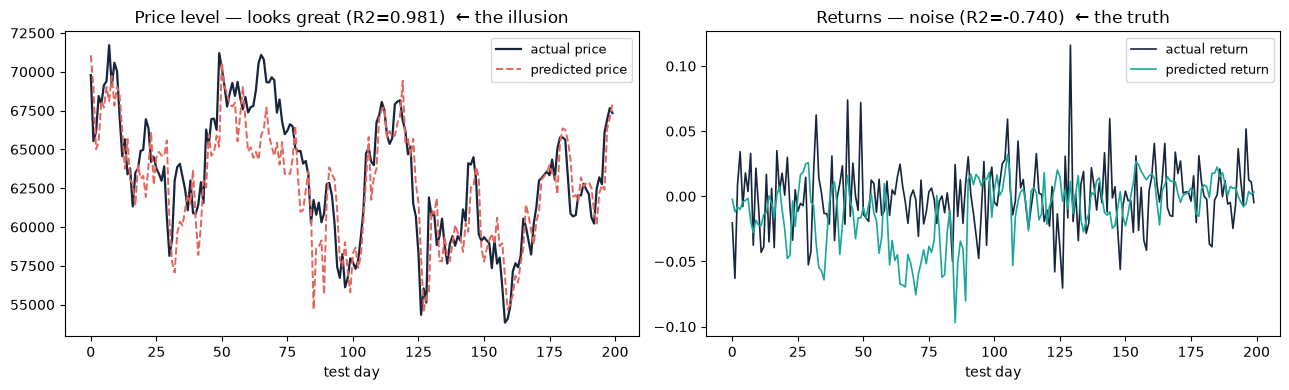

In [16]:
# The two plots — the contrast IS the slide.
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
k = min(200, len(P_true))
ax[0].plot(P_true[:k], color="#16243C", lw=1.6, label="actual price")
ax[0].plot(P_pred[:k], color="#E4655C", lw=1.4, ls="--", label="predicted price")
ax[0].set_title(f"Price level — looks great (R2={r2_score(P_true, P_pred):.3f})  ← the illusion")
ax[0].legend(fontsize=9); ax[0].set_xlabel("test day")
ax[1].plot(R_true[:k], color="#16243C", lw=1.2, label="actual return")
ax[1].plot(R_pred[:k], color="#1AA79A", lw=1.2, label="predicted return")
ax[1].set_title(f"Returns — noise (R2={r2_score(R_true, R_pred):.3f})  ← the truth")
ax[1].legend(fontsize=9); ax[1].set_xlabel("test day")
plt.tight_layout(); plt.show()

## Section 9 — Writing it up

**What this stage establishes** (the capacity ceiling):
- **Direction:** LSTM vs DLinear vs XGBoost — the LSTM does not beat a trivial linear baseline, so the limit is the **data, not model capacity**. This agrees with the null found in every other stage (`docs/CONCLUSIONS.md`).
- **Persistence demo (Section 8):** predicting price **levels** yields R²≈0.99 (just "tomorrow ≈ today" shifted a day); predicting **returns** collapses toward ≈0 R² and ~50% directional accuracy. That is the point — impressive-looking crypto-DL R² can measure the wrong thing.

**Where it goes in the thesis:** the capacity-ceiling result strengthens the null; the persistence demo is a worked example for `docs/CONFOUNDS.md` (Trap 1 + missing baseline); cite Zeng et al. (*Are Transformers Effective for Time Series Forecasting?*, AAAI 2023 — the DLinear result) in related work. Plain-language walkthrough: `docs/LSTM_EXPLAINED.md`.